# Machine Learning Foundation

## Section 1, Part c: EDA Lab

## Question 1

Load the Iris dataset from the local CSV file and examine it.

Determine the following:

* The number of data points (rows). (*Hint:* check out the dataframe `.shape` attribute.)
* The column names. (*Hint:* check out the dataframe `.columns` attribute.)
* The data types for each column. (*Hint:* check out the dataframe `.dtypes` attribute.)

In [8]:
from pathlib import Path

import pandas as pd
from IPython.display import display

data_path = Path("data") / "iris.csv"
iris_df = pd.read_csv(data_path)

numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

display(iris_df.head())


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
print(f"Rows: {iris_df.shape[0]}")
print(f"Columns: {iris_df.shape[1]}")
print("\nColumn names:")
print(list(iris_df.columns))
print("\nData types:")
print(iris_df.dtypes)


Rows: 150
Columns: 5

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


## Question 2

Examine the species names and note that they all begin with 'Iris-'. Remove this portion of the name so the species name is shorter. 

*Hint:* there are multiple ways to do this, but you could use either the [string processing methods](http://pandas.pydata.org/pandas-docs/stable/text.html) or the [apply method](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.apply.html).

In [10]:
iris_df["species"] = iris_df["species"].str.replace("Iris-", "", regex=False)

display(iris_df.head())
print(sorted(iris_df["species"].unique()))


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


['setosa', 'versicolor', 'virginica']


## Question 3

Determine the following:  
* The number of each species present. (*Hint:* check out the series `.value_counts` method.)
* The mean, median, and quantiles and ranges (max-min) for each petal and sepal measurement.

*Hint:* for the last question, the `.describe` method does have median, but it's not called median. It's the *50%* quantile. `.describe` does not have range though, and in order to get the range, you will need to create a new entry in the `.describe` table, which is `max - min`.


In [11]:
species_counts = iris_df["species"].value_counts().sort_index()

measurement_summary = iris_df[numeric_cols].describe().T
measurement_summary["median"] = iris_df[numeric_cols].median()
measurement_summary["range"] = measurement_summary["max"] - measurement_summary["min"]
measurement_summary = measurement_summary[["count", "mean", "std", "min", "25%", "median", "75%", "max", "range"]]

display(species_counts.rename("count").to_frame())
display(measurement_summary)


,count
species,
setosa,50
versicolor,50
virginica,50


,count,mean,std,min,25%,median,75%,max,range
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9,3.6
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4,2.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9,5.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5,2.4


## Question 4

Calculate the following **for each species** in a separate dataframe:

* The mean of each measurement (sepal_length, sepal_width, petal_length, and petal_width).
* The median of each of these measurements.

*Hint:* you may want to use Pandas [`groupby` method](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html) to group by species before calculating the statistic.

If you finish both of these, try calculating both statistics (mean and median) in a single table (i.e. with a single groupby call). See the section of the Pandas documentation on [applying multiple functions at once](http://pandas.pydata.org/pandas-docs/stable/groupby.html#applying-multiple-functions-at-once) for a hint.


In [12]:
species_mean = iris_df.groupby("species")[numeric_cols].mean()
species_median = iris_df.groupby("species")[numeric_cols].median()
species_summary = iris_df.groupby("species")[numeric_cols].agg(["mean", "median"])

display(species_mean)
display(species_median)
display(species_summary)


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

## Question 5

Make a scatter plot of `sepal_length` vs `sepal_width` using Matplotlib. Label the axes and give the plot a title.


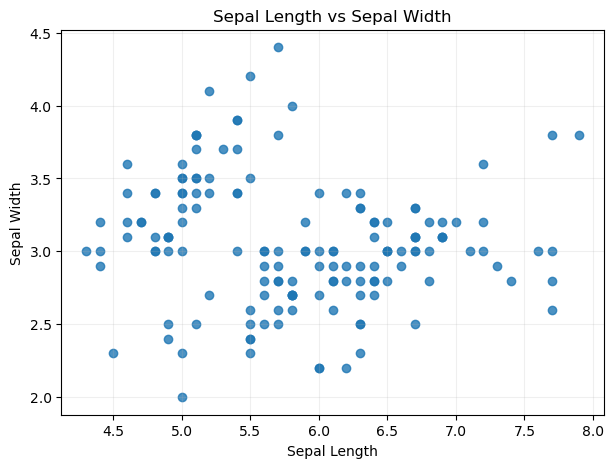

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(iris_df["sepal_length"], iris_df["sepal_width"], alpha=0.8)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Sepal Length vs Sepal Width")
plt.grid(alpha=0.2)
plt.show()


## Question 6

Make a histogram of any one of the four features. Label axes and title it as appropriate. 


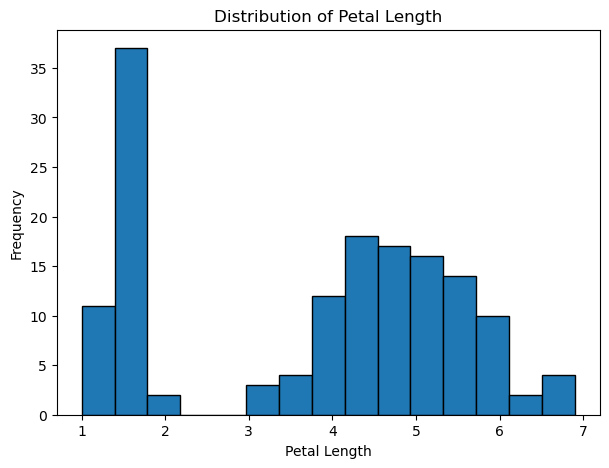

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.hist(iris_df["petal_length"], bins=15, edgecolor="black")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.title("Distribution of Petal Length")
plt.show()


## Question 7

Now create a single plot with histograms for each feature (`petal_width`, `petal_length`, `sepal_width`, `sepal_length`) overlayed. If you have time, next try to create four individual histogram plots in a single figure, where each plot contains one feature.

For some hints on how to do this with Pandas plotting methods, check out the [visualization guide](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html) for Pandas.


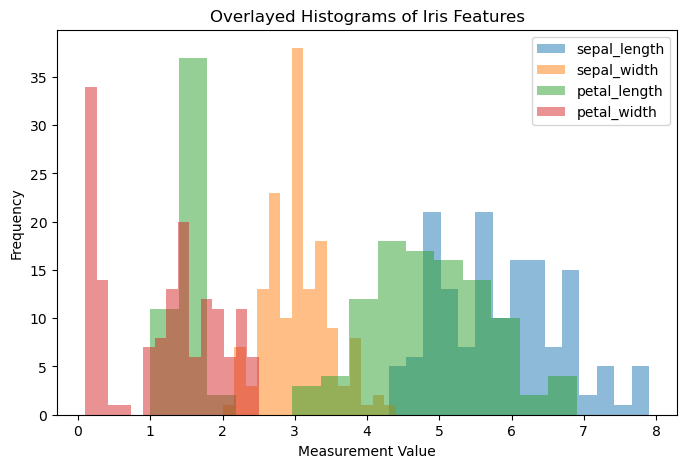

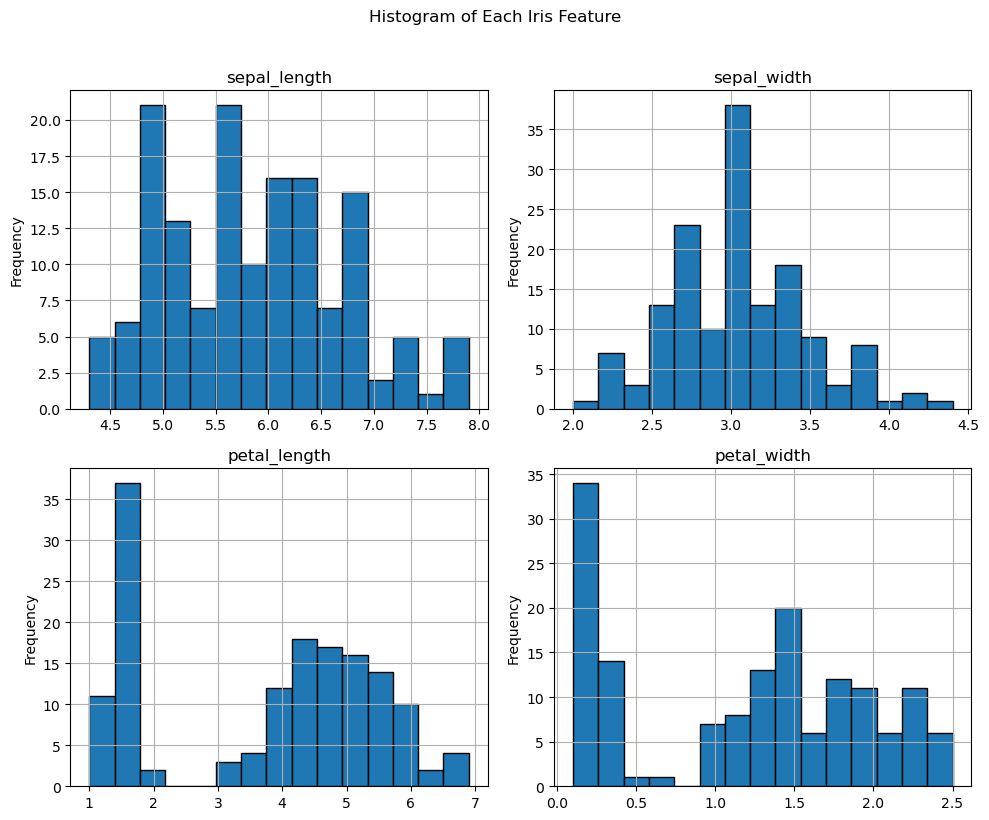

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for column in numeric_cols:
    plt.hist(iris_df[column], bins=15, alpha=0.5, label=column)
plt.xlabel("Measurement Value")
plt.ylabel("Frequency")
plt.title("Overlayed Histograms of Iris Features")
plt.legend()
plt.show()

axes = iris_df[numeric_cols].hist(figsize=(10, 8), bins=15, edgecolor="black")
for ax in axes.ravel():
    ax.set_ylabel("Frequency")
plt.suptitle("Histogram of Each Iris Feature", y=1.02)
plt.tight_layout()


## Question 8

Using Pandas, make a boxplot of each petal and sepal measurement. Here is the documentation for [Pandas boxplot method](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html#visualization-box).


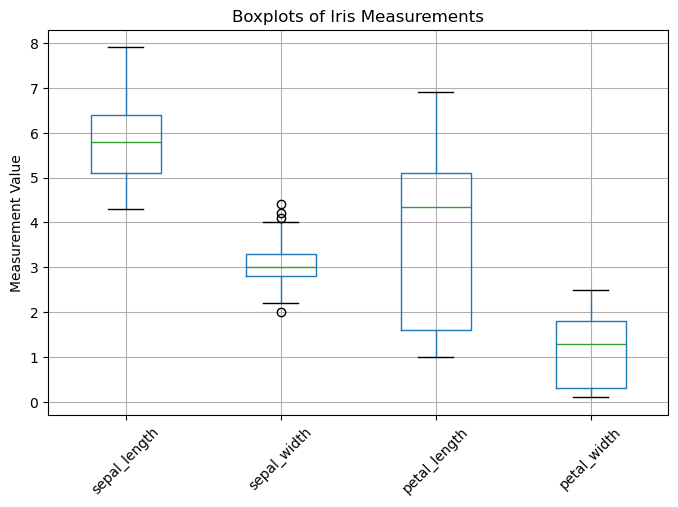

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
iris_df[numeric_cols].boxplot()
plt.title("Boxplots of Iris Measurements")
plt.ylabel("Measurement Value")
plt.xticks(rotation=45)
plt.show()


## Question 9

Now make a single boxplot where the features are separated in the x-axis and species are colored with different hues. 

*Hint:* you may want to check the documentation for [Seaborn boxplots](http://seaborn.pydata.org/generated/seaborn.boxplot.html). 

Also note that Seaborn is very picky about data format--for this plot to work, the input dataframe will need to be manipulated so that each row contains a single data point (a species, a measurement type, and the measurement value). Check out Pandas [stack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.stack.html) method as a starting place.

Here is an example of a data format that will work:

|   | species | measurement  | size |
| - | ------- | ------------ | ---- |
| 0	| setosa  | sepal_length | 5.1  |
| 1	| setosa  | sepal_width  | 3.5  |


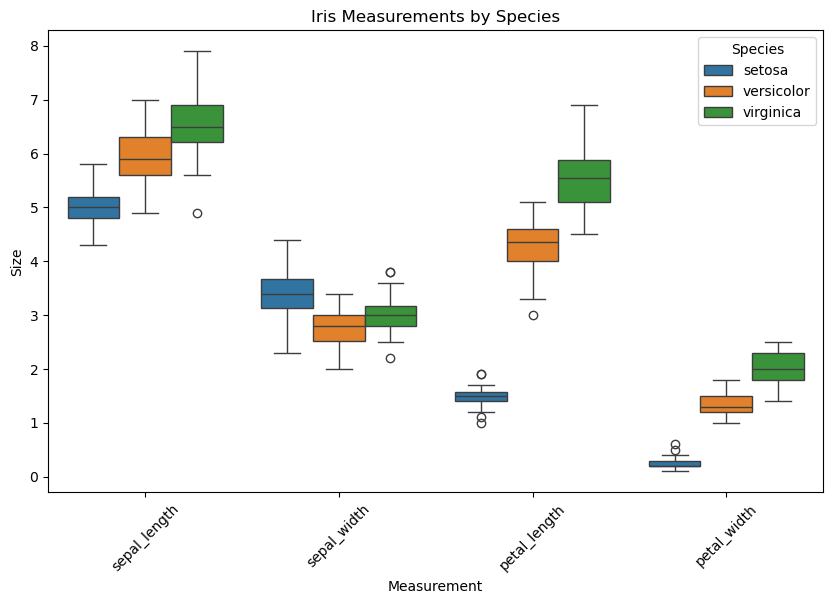

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

iris_long = iris_df.melt(
    id_vars="species",
    value_vars=numeric_cols,
    var_name="measurement",
    value_name="size"
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_long, x="measurement", y="size", hue="species")
plt.title("Iris Measurements by Species")
plt.xlabel("Measurement")
plt.ylabel("Size")
plt.xticks(rotation=45)
plt.legend(title="Species")
plt.show()


## Question 10

Make a [pairplot](http://seaborn.pydata.org/generated/seaborn.pairplot.html) with Seaborn to examine the correlation between each of the measurements.

*Hint:* this plot may look complicated, but it is actually only a single line of code. This is the power of Seaborn and dataframe-aware plotting! See the lecture notes for reference.


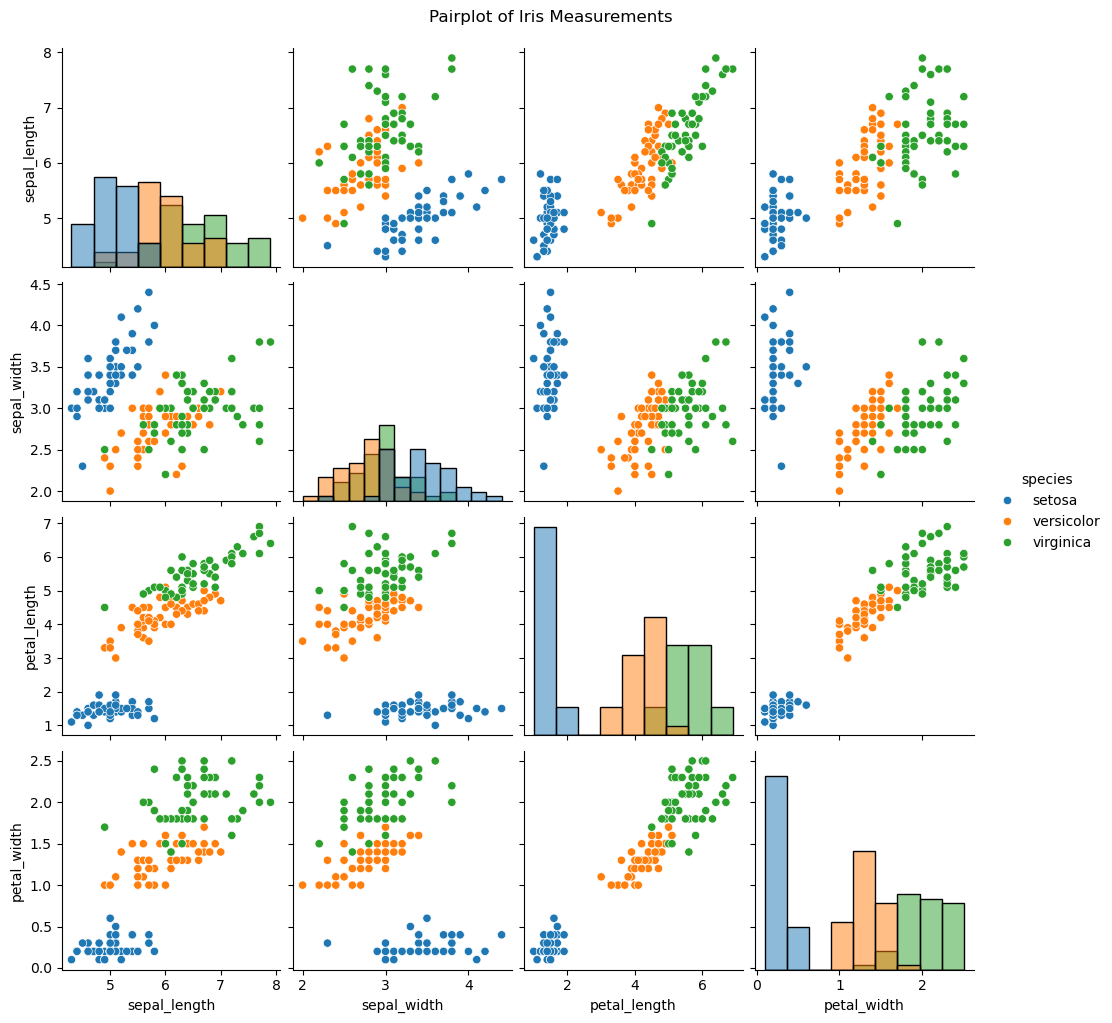

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

pairplot = sns.pairplot(iris_df, hue="species", diag_kind="hist")
pairplot.fig.suptitle("Pairplot of Iris Measurements", y=1.02)
plt.show()
